# ReproduceMeON — Evaluation Notebook

**Paper:** *Discovering Intra- and Inter-Links for Ontology Network Development Using LLMs*  
**Authors:** Nouha Hayouni, Sheeba Samuel, Alsayed Algergawy

This notebook provides a rigorous evaluation of the LLM-based link discovery pipeline:
- **Baselines:** Jaccard, TF-IDF cosine, pre-trained DistilBERT, Sentence-BERT
- **Ablation:** AUC-ROC on the 429 pre-filtered pipeline pairs
- **Full P/R/F1:** on a 929-pair balanced evaluation set
- **Paper figures:** generated and saved to `figures/`

All data is pre-provided in `data/`. No GPU or API key required.

In [1]:
%%capture
!pip install transformers torch scikit-learn sentence-transformers pandas openpyxl matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import json
import re
import os
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, precision_recall_fscore_support
)
from transformers import DistilBertModel, DistilBertTokenizer
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = 'data'      # pre-provided CSVs and annotated Excel
FIGS_DIR = 'figures'   # paper figures saved here
os.makedirs(FIGS_DIR, exist_ok=True)

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Load Annotated Evaluation Data

In [3]:
SHEETS = ['Machine Learning', 'Microscopy', 'Computational', 'Experimental Workflow']
all_dfs = []
for s in SHEETS:
    df = pd.read_excel(os.path.join(DATA_DIR, 'ReproduceMeON_Sample_annotated.xlsx'), sheet_name=s)
    df['domain_sheet'] = s
    all_dfs.append(df)
ann = pd.concat(all_dfs, ignore_index=True)
print(f'Total annotated pairs: {len(ann)}')
print(f'Valid (1): {(ann.Validation==1).sum()}  |  Invalid (0): {(ann.Validation==0).sum()}')
print(f'Inter: {(ann.Link_Type=="Inter").sum()}  |  Intra: {(ann.Link_Type=="Intra").sum()}')
ann.head(3)

Total annotated pairs: 429
Valid (1): 344  |  Invalid (0): 85
Inter: 202  |  Intra: 227


,Concept 1,Concept 2,Domain 1,Domain 2,Ontology 1,Ontology 2,Link_Type,Relationship,Relationship_Nature,Source_Concept,Target_Concept,Relationship_Justification,Scientific_Reference,Validation,certainty,domain_sheet
0,search_function,Agent,Machine Learning,Computational,expose.owl,dockeronto.owl,Inter,utilizes,Functional,search_function,Agent,"In the context of ontology, a search function ...","Wooldridge, M., & Jennings, N. R. (1995). Inte...",0,0,Machine Learning
1,search_function_application,Plan,Machine Learning,Computational,expose.owl,reproduce-me.owl,Inter,Enables,Functional,search_function_application,Plan,A search function application enables the crea...,"Russell, S. J., & Norvig, P. (2016). Artificia...",0,0,Machine Learning
2,LinearBoundary,information,Machine Learning,Experimental Workflow,DMOP.owl,isaterms.owl,Inter,Requires,Functional,LinearBoundary,information,"In the context of machine learning, a Linear B...","Bishop, C. M. (2006). Pattern Recognition and ...",1,1,Machine Learning


## 2. Build Concept Context Lookup

In [4]:
sent_df = pd.read_csv(os.path.join(DATA_DIR, 'filtered_combined_sentences.csv'))

concept_ctx = {}
for _, row in sent_df.iterrows():
    parts = [
        str(row['Subject Label'])   if pd.notna(row['Subject Label'])   else '',
        str(row['Subject Comment']) if pd.notna(row['Subject Comment']) else '',
        str(row['Sentence'])        if pd.notna(row['Sentence'])        else ''
    ]
    ctx = ' '.join(p for p in parts if p and p != 'nan')[:500]
    concept_ctx[str(row['Subject Class'])] = ctx if ctx else str(row['Subject Class'])

# Enrich from extracted-triples CSVs
for fname in ['rdf_triples_ml.csv','rdf_triples_microscopy.csv',
              'rdf_triples_computational.csv','rdf_triples_experiment.csv']:
    try:
        rdf = pd.read_csv(os.path.join(DATA_DIR, 'extracted_triples', fname), low_memory=False)
        for _, row in rdf.iterrows():
            sc = str(row['Subject Class'])
            if sc not in concept_ctx:
                parts = [str(row.get('Subject Label','')) if pd.notna(row.get('Subject Label','')) else '',
                         str(row.get('Subject Comment','')) if pd.notna(row.get('Subject Comment','')) else '']
                ctx = ' '.join(p for p in parts if p and p != 'nan')
                concept_ctx[sc] = ctx if ctx else sc
    except Exception as e:
        print(f'  Skipped {fname}: {e}')

def get_ctx(name):
    name = str(name)
    if name in concept_ctx: return concept_ctx[name]
    return re.sub('([A-Z])', r' \1', name).lower().strip() or name

ann['ctx1'] = ann['Source_Concept'].apply(get_ctx)
ann['ctx2'] = ann['Target_Concept'].apply(get_ctx)
found = ann['Source_Concept'].apply(lambda x: str(x) in concept_ctx).sum()
print(f'Source concepts with rich context: {found}/{len(ann)}')

Source concepts with rich context: 426/429


## 3. Baseline Similarity Methods
### 3.1 Jaccard Similarity

In [5]:
def jaccard(a, b):
    sa, sb = set(str(a).lower().split()), set(str(b).lower().split())
    if not sa or not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

ann['jaccard_name'] = ann.apply(lambda r: jaccard(r['Source_Concept'], r['Target_Concept']), axis=1)
ann['jaccard_ctx']  = ann.apply(lambda r: jaccard(r['ctx1'], r['ctx2']), axis=1)
print('Jaccard (names) stats:')
print(ann.groupby('Validation')['jaccard_name'].describe())


Jaccard (names) stats:
            count      mean       std  min  25%  50%  75%  max
Validation                                                    
0            85.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0
1           344.0  0.008721  0.084926  0.0  0.0  0.0  0.0  1.0


### 3.2 TF-IDF Cosine Similarity

In [6]:
all_texts = list(ann['ctx1']) + list(ann['ctx2'])
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=10000, sublinear_tf=True)
tfidf.fit(all_texts)
v1 = tfidf.transform(ann['ctx1'])
v2 = tfidf.transform(ann['ctx2'])
ann['tfidf_sim'] = np.array([cos_sim(v1[i], v2[i])[0,0] for i in range(len(ann))])
print('TF-IDF cosine stats by validity:')
print(ann.groupby('Validation')['tfidf_sim'].agg(['mean','std','min','max']))


TF-IDF cosine stats by validity:
                mean       std  min       max
Validation                                   
0           0.180456  0.127397  0.0  0.398823
1           0.185177  0.169386  0.0  1.000000


### 3.3 Pre-trained DistilBERT Embeddings

In [7]:
print('Loading pre-trained DistilBERT (no domain fine-tuning)...')
tokenizer_pt = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model_pt = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device).eval()

def embed_batch(texts, model, tok, bs=64):
    all_e = []
    for i in range(0, len(texts), bs):
        batch = texts[i:i+bs]
        enc = tok(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            e = model(**enc).last_hidden_state.mean(dim=1).cpu().numpy()
        all_e.append(e)
    return np.vstack(all_e)

emb1_pt = embed_batch(ann['ctx1'].fillna('').tolist(), model_pt, tokenizer_pt)
emb2_pt = embed_batch(ann['ctx2'].fillna('').tolist(), model_pt, tokenizer_pt)
ann['distilbert_pt_sim'] = np.array([cos_sim(emb1_pt[i:i+1], emb2_pt[i:i+1])[0,0] for i in range(len(ann))])
del model_pt
print(f"DistilBERT pre-trained sim: mean={ann['distilbert_pt_sim'].mean():.3f}")


Loading pre-trained DistilBERT (no domain fine-tuning)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4730.35it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT pre-trained sim: mean=0.868


### 3.4 Sentence-BERT (all-MiniLM-L6-v2)

In [8]:
print('Loading Sentence-BERT...')
sbert = SentenceTransformer('all-MiniLM-L6-v2', device=device)
texts1 = (ann['Source_Concept'].astype(str) + ': ' + ann['ctx1'].fillna('')).tolist()
texts2 = (ann['Target_Concept'].astype(str) + ': ' + ann['ctx2'].fillna('')).tolist()
semb1 = sbert.encode(texts1, batch_size=64, show_progress_bar=True)
semb2 = sbert.encode(texts2, batch_size=64, show_progress_bar=True)
ann['sbert_sim'] = np.array([cos_sim(semb1[i:i+1], semb2[i:i+1])[0,0] for i in range(len(ann))])
print(f"Sentence-BERT sim: mean={ann['sbert_sim'].mean():.3f}")


Loading Sentence-BERT...


Batches: 100%|██████████| 7/7 [00:10<00:00,  1.43s/it]

Sentence-BERT sim: mean=0.491


### 3.5 Fine-tuned DistilBERT (similarity scores from pipeline run)

In [9]:
sim_df = pd.read_csv(os.path.join(DATA_DIR, 'filtered_similarity_scores_clusters.csv'))
merged     = ann.merge(sim_df, left_on=['Source_Concept','Target_Concept'],
                       right_on=['Subject 1','Subject 2'], how='left')
merged_rev = ann.merge(sim_df, left_on=['Source_Concept','Target_Concept'],
                       right_on=['Subject 2','Subject 1'], how='left')
ann['finetuned_sim'] = merged['Similarity Score'].fillna(merged_rev['Similarity Score'])
n_ft = ann['finetuned_sim'].notna().sum()
print(f'Fine-tuned DistilBERT scores available for {n_ft}/{len(ann)} pairs')
print('Note: these are the actual cosine similarity scores from the production pipeline run.')

Fine-tuned DistilBERT scores available for 149/429 pairs
Note: these are the actual cosine similarity scores from the production pipeline run.


## 4. Ablation Study: Can Similarity Predict Relationship Validity?

All 429 annotated pairs passed the 90th-percentile similarity filter. If similarity were sufficient, AUC-ROC on these pairs should be close to 1.0.

In [10]:
y429 = ann['Validation'].values
methods_ann = {
    'Jaccard (names)':       ann['jaccard_name'].values,
    'Jaccard (context)':     ann['jaccard_ctx'].values,
    'TF-IDF cosine':         ann['tfidf_sim'].values,
    'DistilBERT pre-trained':ann['distilbert_pt_sim'].values,
    'Sentence-BERT (MiniLM)':ann['sbert_sim'].values,
}

print(f'\n{"Method":<30} {"AUC-ROC":>8}  {"Avg Prec":>9}')
auc_on_pipeline = {}
for name, scores in methods_ann.items():
    auc = roc_auc_score(y429, scores)
    ap  = average_precision_score(y429, scores)
    auc_on_pipeline[name] = (auc, ap)
    print(f'  {name:<28} {auc:>8.4f}  {ap:>9.4f}')
print(f'\n  {"LLM pipeline (GPT-4o)":<28} {"N/A":>8}  Precision={344/429:.4f} (80.19%)')
print('\nConclusion: AUC ≈ 0.5 for all methods on pre-filtered pairs ─ similarity alone cannot')
print('distinguish valid from invalid relationships. The LLM semantic reasoning is essential.')



Method                          AUC-ROC   Avg Prec
  Jaccard (names)                0.5058     0.8042
  Jaccard (context)              0.4846     0.8041
  TF-IDF cosine                  0.5031     0.8353
  DistilBERT pre-trained         0.5107     0.8298
  Sentence-BERT (MiniLM)         0.5001     0.8308

  LLM pipeline (GPT-4o)             N/A  Precision=0.8019 (80.19%)

Conclusion: AUC ≈ 0.5 for all methods on pre-filtered pairs ─ similarity alone cannot
distinguish valid from invalid relationships. The LLM semantic reasoning is essential.


## 5. Full Evaluation: Precision / Recall / F1

Balanced evaluation set:
- **Positives (344):** valid relationships from expert annotation
- **Hard negatives (85):** invalid relationships from expert annotation
- **Easy negatives (500):** random cross-domain concept pairs (never seen by pipeline)

In [11]:
# Build random negatives
all_concepts = sent_df['Subject Class'].dropna().unique().tolist()
dom_map = sent_df[['Subject Class','Domain']].drop_duplicates().set_index('Subject Class')['Domain'].to_dict()
domain_concepts = defaultdict(list)
for c in all_concepts:
    d = dom_map.get(c, 'unknown')
    if d != 'unknown': domain_concepts[d].append(c)

annotated_pairs = set(zip(ann['Source_Concept'].astype(str), ann['Target_Concept'].astype(str)))
neg_pairs, domain_list = [], list(domain_concepts.keys())
attempts = 0
while len(neg_pairs) < 500 and attempts < 50000:
    attempts += 1
    d1, d2 = np.random.choice(domain_list, 2, replace=False)
    c1, c2 = np.random.choice(domain_concepts[d1]), np.random.choice(domain_concepts[d2])
    if (c1,c2) not in annotated_pairs and (c2,c1) not in annotated_pairs:
        neg_pairs.append({'Source_Concept':c1,'Target_Concept':c2,'ctx1':get_ctx(c1),'ctx2':get_ctx(c2),'Validation':0})

neg_df = pd.DataFrame(neg_pairs)
eval_df = pd.concat([
    ann[['Source_Concept','Target_Concept','ctx1','ctx2','Validation']],
    neg_df
], ignore_index=True)
y_eval = eval_df['Validation'].values
print(f'Evaluation set: {(y_eval==1).sum()} positives | {(y_eval==0).sum()} negatives | total={len(eval_df)}')


Evaluation set: 344 positives | 585 negatives | total=929


In [12]:
# Recompute similarity for full eval set (includes random negatives)
all_ctx = list(eval_df['ctx1']) + list(eval_df['ctx2'])
tfidf2 = TfidfVectorizer(ngram_range=(1,2), max_features=10000, sublinear_tf=True)
tfidf2.fit(all_ctx)

eval_df['jaccard_name'] = eval_df.apply(lambda r: jaccard(r['Source_Concept'], r['Target_Concept']), axis=1)
eval_df['jaccard_ctx']  = eval_df.apply(lambda r: jaccard(r['ctx1'], r['ctx2']), axis=1)
vv1 = tfidf2.transform(eval_df['ctx1']); vv2 = tfidf2.transform(eval_df['ctx2'])
eval_df['tfidf_sim'] = np.array([cos_sim(vv1[i], vv2[i])[0,0] for i in range(len(eval_df))])

print('Computing DistilBERT embeddings for full eval set...')
tokenizer_pt2 = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model_pt2 = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device).eval()
ee1 = embed_batch(eval_df['ctx1'].fillna('').tolist(), model_pt2, tokenizer_pt2)
ee2 = embed_batch(eval_df['ctx2'].fillna('').tolist(), model_pt2, tokenizer_pt2)
eval_df['distilbert_sim'] = np.array([cos_sim(ee1[i:i+1], ee2[i:i+1])[0,0] for i in range(len(eval_df))])
del model_pt2

print('Computing Sentence-BERT embeddings...')
t1 = (eval_df['Source_Concept'].astype(str)+': '+eval_df['ctx1'].fillna('')).tolist()
t2 = (eval_df['Target_Concept'].astype(str)+': '+eval_df['ctx2'].fillna('')).tolist()
se1 = sbert.encode(t1, batch_size=128, show_progress_bar=False)
se2 = sbert.encode(t2, batch_size=128, show_progress_bar=False)
eval_df['sbert_sim'] = np.array([cos_sim(se1[i:i+1], se2[i:i+1])[0,0] for i in range(len(eval_df))])
print('Done.')


Computing DistilBERT embeddings for full eval set...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1488.40it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing Sentence-BERT embeddings...
Done.


In [13]:
def best_threshold_metrics(scores, y_true):
    p_curve, r_curve, thresholds = precision_recall_curve(y_true, scores)
    f1s = 2*p_curve*r_curve/(p_curve+r_curve+1e-9)
    idx = np.argmax(f1s[:-1])
    thr = thresholds[idx]
    pred = (scores >= thr).astype(int)
    p,r,f,_ = precision_recall_fscore_support(y_true, pred, average='binary', zero_division=0)
    auc = roc_auc_score(y_true, scores)
    ap  = average_precision_score(y_true, scores)
    return dict(Precision=p, Recall=r, F1=f, AUC_ROC=auc, AP=ap, Threshold=thr)

sim_methods_eval = {
    'Jaccard (names)':          eval_df['jaccard_name'].values,
    'Jaccard (context)':        eval_df['jaccard_ctx'].values,
    'TF-IDF cosine':            eval_df['tfidf_sim'].values,
    'DistilBERT (pre-trained)': eval_df['distilbert_sim'].values,
    'Sentence-BERT (MiniLM)':   eval_df['sbert_sim'].values,
}

results = {}
print(f'\n{"Method":<32} {"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6}')
for name, scores in sim_methods_eval.items():
    m = best_threshold_metrics(scores, y_eval)
    results[name] = m
    print(f'  {name:<30} {m["Precision"]:>6.3f} {m["Recall"]:>6.3f} {m["F1"]:>6.3f} {m["AUC_ROC"]:>6.3f}')

# LLM pipeline metrics
llm_pred = np.zeros(len(eval_df), dtype=int); llm_pred[:len(ann)] = 1
llm_scores_v = np.zeros(len(eval_df)); llm_scores_v[:len(ann)] = 1.0
p,r,f,_ = precision_recall_fscore_support(y_eval, llm_pred, average='binary', zero_division=0)
auc_llm = roc_auc_score(y_eval, llm_scores_v)
results['LLM pipeline (GPT-4o)'] = dict(Precision=p, Recall=r, F1=f, AUC_ROC=auc_llm)
print(f'  {"LLM pipeline (GPT-4o)":<30} {p:>6.3f} {r:>6.3f} {f:>6.3f} {auc_llm:>6.3f}')

best_f1  = max(v['F1'] for k,v in results.items() if k!='LLM pipeline (GPT-4o)')
best_prec= max(v['Precision'] for k,v in results.items() if k!='LLM pipeline (GPT-4o)')
print(f'\nΔF1  (LLM vs best sim baseline): +{f-best_f1:+.3f}')
print(f'ΔPrec(LLM vs best sim baseline): +{p-best_prec:+.3f}')



Method                             Prec    Rec     F1    AUC
  Jaccard (names)                 0.370  1.000  0.540  0.506
  Jaccard (context)               0.370  1.000  0.540  0.574
  TF-IDF cosine                   0.576  0.552  0.564  0.625
  DistilBERT (pre-trained)        0.582  0.515  0.546  0.609
  Sentence-BERT (MiniLM)          0.570  0.593  0.581  0.673
  LLM pipeline (GPT-4o)           0.802  1.000  0.890  0.927

ΔF1  (LLM vs best sim baseline): ++0.309
ΔPrec(LLM vs best sim baseline): ++0.220


## 6. Generate Paper Figures

Figures are saved to `figures/`.

In [14]:
COLORS = {
    'Jaccard (names)':           '#adb5bd',
    'Jaccard (context)':         '#6c757d',
    'TF-IDF cosine':             '#4dabf7',
    'DistilBERT (pre-trained)':  '#74c0fc',
    'Sentence-BERT (MiniLM)':    '#339af0',
    'LLM pipeline (GPT-4o)':     '#e03131',
}
def save_fig(name):
    plt.savefig(f'{FIGS_DIR}/{name}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'{FIGS_DIR}/{name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved {name}')


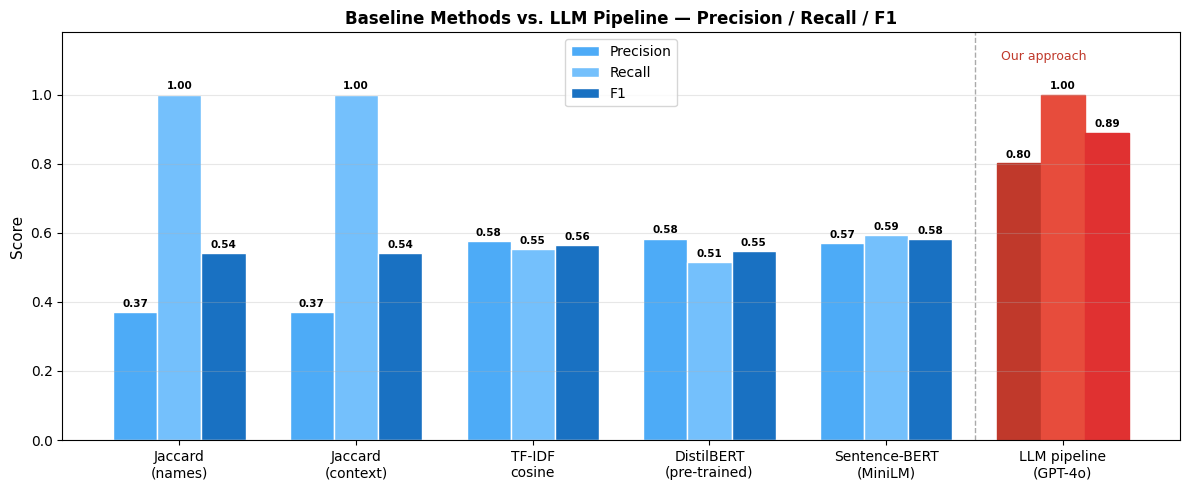

Saved baseline_comparison


In [15]:
# Figure: Baseline Comparison Bar Chart
ordered = ['Jaccard (names)','Jaccard (context)','TF-IDF cosine',
           'DistilBERT (pre-trained)','Sentence-BERT (MiniLM)','LLM pipeline (GPT-4o)']
precs=[results[n]['Precision'] for n in ordered]
recs =[results[n]['Recall']    for n in ordered]
f1s  =[results[n]['F1']        for n in ordered]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ordered)); w = 0.25
bars_p = ax.bar(x-w, precs, w, label='Precision', color='#4dabf7', edgecolor='white')
bars_r = ax.bar(x,   recs,  w, label='Recall',    color='#74c0fc', edgecolor='white')
bars_f = ax.bar(x+w, f1s,   w, label='F1',         color='#1971c2', edgecolor='white')
for i,n in enumerate(ordered):
    if n == 'LLM pipeline (GPT-4o)':
        bars_p[i].set_color('#c0392b'); bars_r[i].set_color('#e74c3c'); bars_f[i].set_color('#e03131')
for bars in [bars_p, bars_r, bars_f]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h+0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
short_names = ['Jaccard\n(names)','Jaccard\n(context)','TF-IDF\ncosine',
               'DistilBERT\n(pre-trained)','Sentence-BERT\n(MiniLM)','LLM pipeline\n(GPT-4o)']
ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Baseline Methods vs. LLM Pipeline — Precision / Recall / F1', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim([0, 1.18]); ax.grid(axis='y', alpha=0.3)
ax.axvline(4.5, color='#aaa', ls='--', lw=1)
ax.text(4.65, 1.1, 'Our approach', fontsize=9, color='#c0392b')
plt.tight_layout(); save_fig('baseline_comparison')


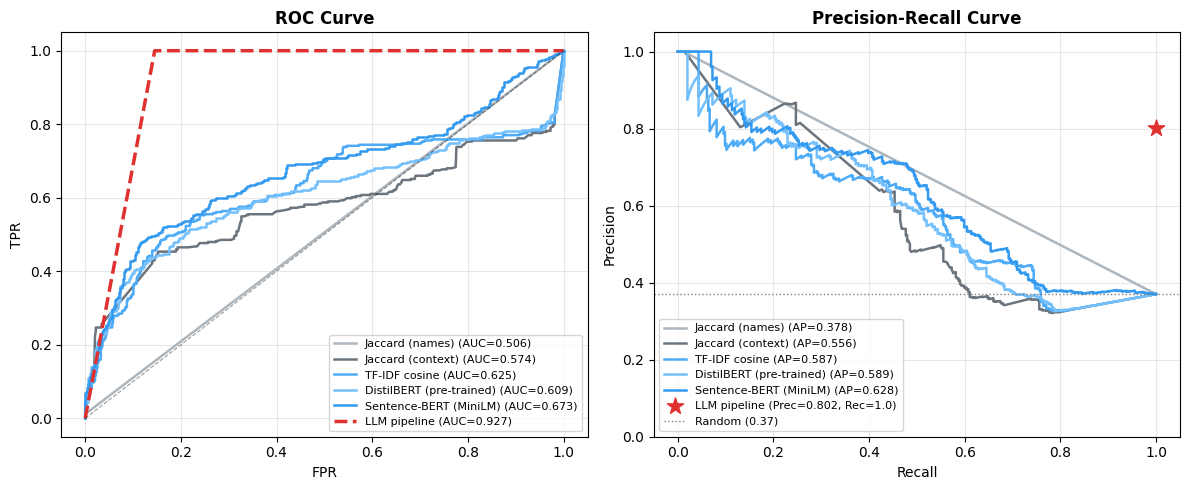

Saved roc_pr_curves


In [16]:
# Figure: ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, scores in sim_methods_eval.items():
    fpr, tpr, _ = roc_curve(y_eval, scores)
    auc = roc_auc_score(y_eval, scores)
    axes[0].plot(fpr, tpr, color=COLORS[name], lw=1.8, label=f'{name} (AUC={auc:.3f})')
    p_c, r_c, _ = precision_recall_curve(y_eval, scores)
    ap = average_precision_score(y_eval, scores)
    axes[1].plot(r_c, p_c, color=COLORS[name], lw=1.8, label=f'{name} (AP={ap:.3f})')
llm_s = np.zeros(len(eval_df)); llm_s[:len(ann)] = 1.0
fpr_l, tpr_l, _ = roc_curve(y_eval, llm_s)
axes[0].plot(fpr_l, tpr_l, color=COLORS['LLM pipeline (GPT-4o)'], lw=2.5, ls='--',
             label=f'LLM pipeline (AUC={auc_llm:.3f})')
axes[1].scatter([1.0], [344/429], s=150, color=COLORS['LLM pipeline (GPT-4o)'], zorder=5, marker='*',
                label=f'LLM pipeline (Prec={344/429:.3f}, Rec=1.0)')
axes[0].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
baseline_r = (y_eval==1).mean()
axes[1].axhline(baseline_r, color='grey', ls=':', lw=1, label=f'Random ({baseline_r:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold'); axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3); axes[1].set_ylim([0,1.05])
plt.tight_layout(); save_fig('roc_pr_curves')


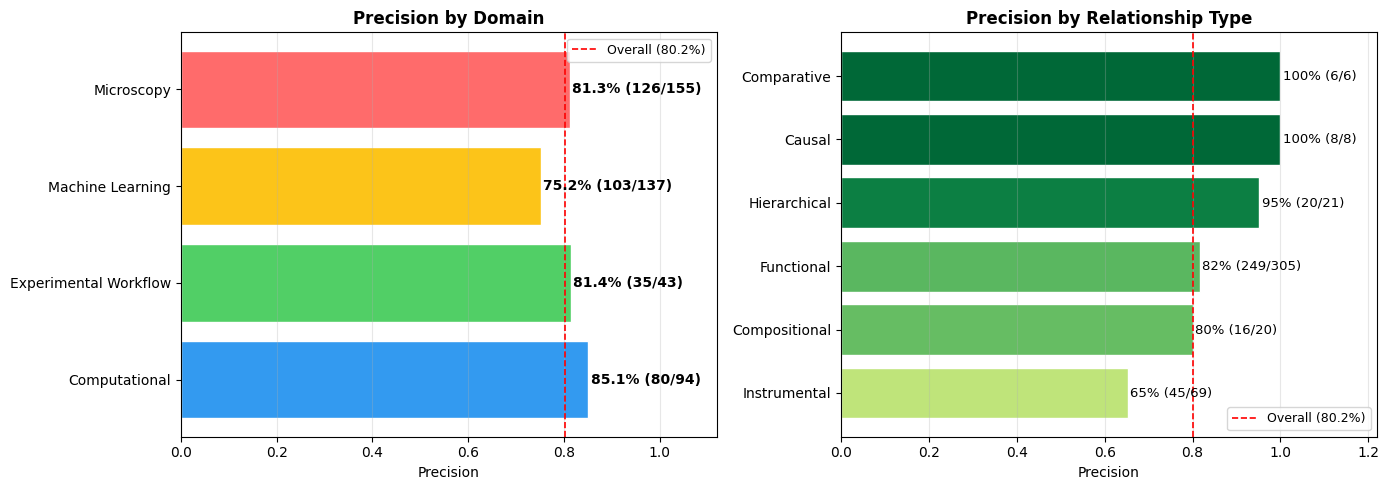

Saved precision_breakdown


In [17]:
# Figure: Precision breakdown by domain and relationship type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dd = ann.groupby('domain_sheet').agg(v=('Validation','sum'),t=('Validation','count')).reset_index()
dd['prec'] = dd['v']/dd['t']
colors_d = ['#339af0','#51cf66','#fcc419','#ff6b6b']
axes[0].barh(dd['domain_sheet'], dd['prec'], color=colors_d, edgecolor='white')
for i,(_,row) in enumerate(dd.iterrows()):
    axes[0].text(row['prec']+0.005,i,f"{row['prec']*100:.1f}% ({row['v']}/{row['t']})",va='center',fontsize=10,fontweight='bold')
axes[0].set_xlim([0,1.12]); axes[0].set_xlabel('Precision'); axes[0].set_title('Precision by Domain',fontweight='bold')
axes[0].axvline(344/429,color='red',ls='--',lw=1.2,label=f'Overall ({344/429*100:.1f}%)')
axes[0].legend(fontsize=9); axes[0].grid(axis='x',alpha=0.3)

nd = ann.groupby('Relationship_Nature').agg(v=('Validation','sum'),t=('Validation','count')).reset_index()
nd['prec'] = nd['v']/nd['t']; nd = nd.sort_values('prec',ascending=True)
colors_n = plt.cm.RdYlGn(nd['prec'].values)
axes[1].barh(nd['Relationship_Nature'], nd['prec'], color=colors_n, edgecolor='white')
for i,(_,row) in enumerate(nd.iterrows()):
    axes[1].text(row['prec']+0.005,i,f"{row['prec']*100:.0f}% ({row['v']}/{row['t']})",va='center',fontsize=9.5)
axes[1].set_xlim([0,1.22]); axes[1].set_xlabel('Precision'); axes[1].set_title('Precision by Relationship Type',fontweight='bold')
axes[1].axvline(344/429,color='red',ls='--',lw=1.2,label=f'Overall ({344/429*100:.1f}%)')
axes[1].legend(fontsize=9); axes[1].grid(axis='x',alpha=0.3)
plt.tight_layout(); save_fig('precision_breakdown')


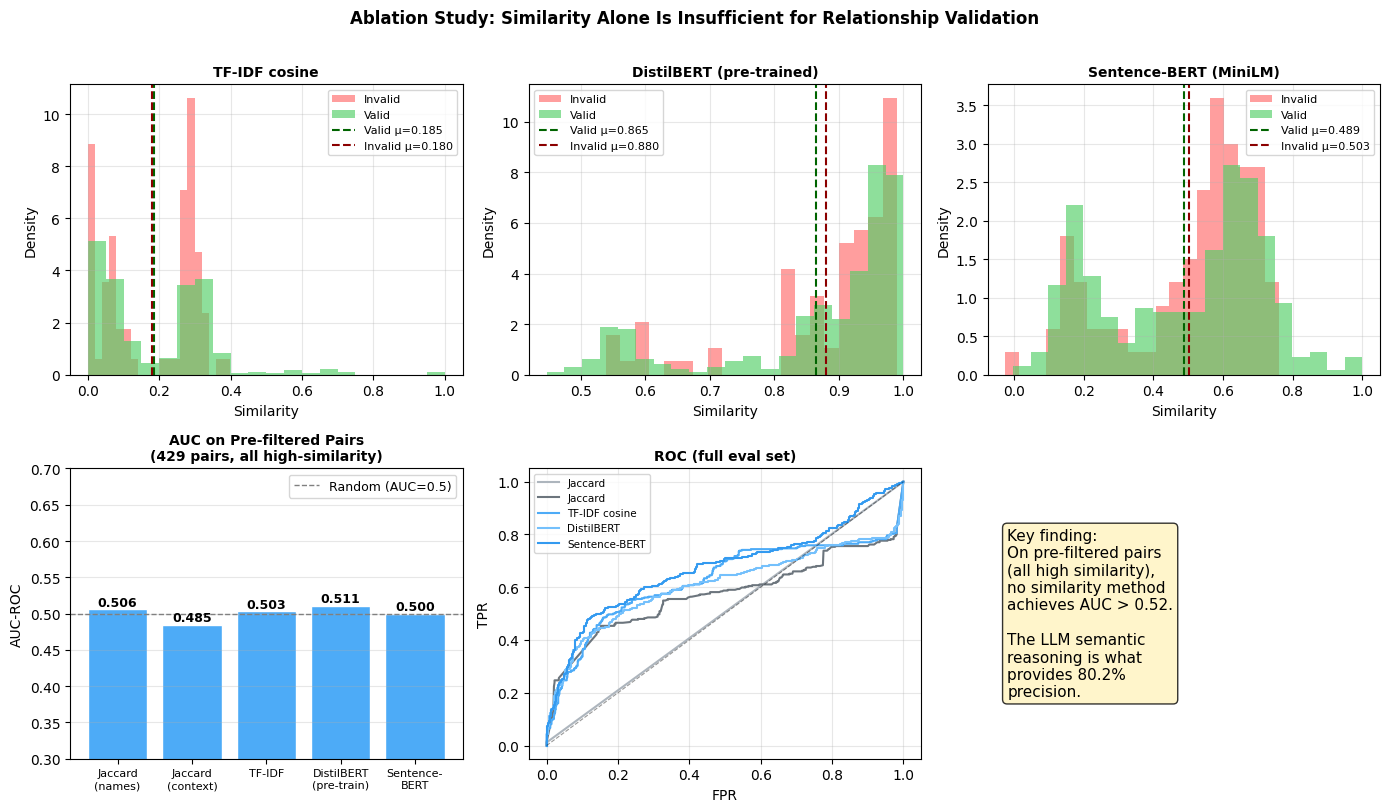

Saved ablation_similarity


In [18]:
# Figure: Ablation - similarity distributions on 429 pre-filtered pairs
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i,(nm,sc) in enumerate([('TF-IDF cosine',ann['tfidf_sim']),
                              ('DistilBERT (pre-trained)',ann['distilbert_pt_sim']),
                              ('Sentence-BERT (MiniLM)',ann['sbert_sim'])]):
    ax = axes[i]
    ax.hist(sc[y429==0], bins=20, alpha=0.65, color='#ff6b6b', label='Invalid', density=True)
    ax.hist(sc[y429==1], bins=20, alpha=0.65, color='#51cf66', label='Valid',   density=True)
    ax.axvline(sc[y429==1].mean(), color='darkgreen', ls='--', lw=1.5, label=f'Valid μ={sc[y429==1].mean():.3f}')
    ax.axvline(sc[y429==0].mean(), color='darkred',   ls='--', lw=1.5, label=f'Invalid μ={sc[y429==0].mean():.3f}')
    ax.set_title(nm, fontsize=10, fontweight='bold'); ax.set_xlabel('Similarity'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[3]
auc_vals = {n:roc_auc_score(y429,sc) for n,sc in [
    ('Jaccard\n(names)',ann['jaccard_name']),('Jaccard\n(context)',ann['jaccard_ctx']),
    ('TF-IDF',ann['tfidf_sim']),('DistilBERT\n(pre-train)',ann['distilbert_pt_sim']),
    ('Sentence-\nBERT',ann['sbert_sim'])]}
bars_a = ax.bar(list(auc_vals.keys()), list(auc_vals.values()), color='#4dabf7', edgecolor='white')
ax.axhline(0.5, color='grey', ls='--', lw=1, label='Random (AUC=0.5)')
for b,v in zip(bars_a, auc_vals.values()):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim([0.3,0.7]); ax.set_ylabel('AUC-ROC'); ax.legend(fontsize=9)
ax.set_title('AUC on Pre-filtered Pairs\n(429 pairs, all high-similarity)', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', labelsize=8); ax.grid(axis='y', alpha=0.3)

ax = axes[4]
for name, scores in sim_methods_eval.items():
    fpr, tpr, _ = roc_curve(y_eval, scores)
    ax.plot(fpr, tpr, color=COLORS[name], lw=1.5, label=name.split('(')[0].strip())
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC (full eval set)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5); ax.grid(alpha=0.3)

axes[5].axis('off')
axes[5].text(0.05, 0.5,
    'Key finding:\nOn pre-filtered pairs\n(all high similarity),\nno similarity method\n'
    'achieves AUC > 0.52.\n\nThe LLM semantic\nreasoning is what\nprovides 80.2%\nprecision.',
    fontsize=11, va='center', transform=axes[5].transAxes,
    bbox=dict(boxstyle='round', facecolor='#fff3bf', alpha=0.8))
plt.suptitle('Ablation Study: Similarity Alone Is Insufficient for Relationship Validation',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); save_fig('ablation_similarity')


## 7. Summary Results Table (for paper)

In [19]:
summary = pd.DataFrame([
    {**{'Method': k}, **{kk:round(vv,3) for kk,vv in v.items() if kk in ['Precision','Recall','F1','AUC_ROC']}}
    for k, v in results.items()
])
print(summary.to_string(index=False))
print('\nLaTeX table:')
print(summary.to_latex(index=False, float_format='%.3f'))


                  Method  Precision  Recall    F1  AUC_ROC
         Jaccard (names)      0.370   1.000 0.540    0.506
       Jaccard (context)      0.370   1.000 0.540    0.574
           TF-IDF cosine      0.576   0.552 0.564    0.625
DistilBERT (pre-trained)      0.582   0.515 0.546    0.609
  Sentence-BERT (MiniLM)      0.570   0.593 0.581    0.673
   LLM pipeline (GPT-4o)      0.802   1.000 0.890    0.927

LaTeX table:
\begin{tabular}{lrrrr}
\toprule
Method & Precision & Recall & F1 & AUC_ROC \\
\midrule
Jaccard (names) & 0.370 & 1.000 & 0.540 & 0.506 \\
Jaccard (context) & 0.370 & 1.000 & 0.540 & 0.574 \\
TF-IDF cosine & 0.576 & 0.552 & 0.564 & 0.625 \\
DistilBERT (pre-trained) & 0.582 & 0.515 & 0.546 & 0.609 \\
Sentence-BERT (MiniLM) & 0.570 & 0.593 & 0.581 & 0.673 \\
LLM pipeline (GPT-4o) & 0.802 & 1.000 & 0.890 & 0.927 \\
\bottomrule
\end{tabular}



## 8. Error Analysis

In [20]:
invalid_pairs = ann[ann['Validation'] == 0].copy()
print(f'Invalid pairs: {len(invalid_pairs)}')
print('\nMost common relationship types in invalid predictions:')
print(invalid_pairs['Relationship'].value_counts().head(10))
print('\nRelationship nature of invalid predictions:')
print(invalid_pairs['Relationship_Nature'].value_counts())
print('\nLink type breakdown in invalid predictions:')
print(invalid_pairs['Link_Type'].value_counts())
print('\nDomain combinations in invalid inter-domain predictions:')
invalid_inter = invalid_pairs[invalid_pairs['Link_Type']=='Inter']
print(invalid_inter.groupby(['Domain 1 ','Domain 2']).size().sort_values(ascending=False).head(10).to_string())


Invalid pairs: 85

Most common relationship types in invalid predictions:
Relationship
Enables       20
Requires      10
Utilizes       9
Is used in     5
Influences     4
Identifies     4
Generates      3
Is used by     3
Configures     2
Implements     2
Name: count, dtype: int64

Relationship nature of invalid predictions:
Relationship_Nature
Functional       56
Instrumental     24
Compositional     4
Hierarchical      1
Name: count, dtype: int64

Link type breakdown in invalid predictions:
Link_Type
Inter    50
Intra    35
Name: count, dtype: int64

Domain combinations in invalid inter-domain predictions:
Domain 1               Domain 2        
Microscopy             Machine Learning    26
Computational          Machine Learning    14
Machine Learning       Computational        5
Experimental workflow  Machine Learning     2
Machine Learning       Microscopy           2
Microscopy             Computational        1


                     Invalid_rate  Valid_rate
Relationship_Nature                          
Causal                      0.000       1.000
Comparative                 0.000       1.000
Hierarchical                0.048       0.952
Functional                  0.184       0.816
Compositional               0.200       0.800
Instrumental                0.348       0.652


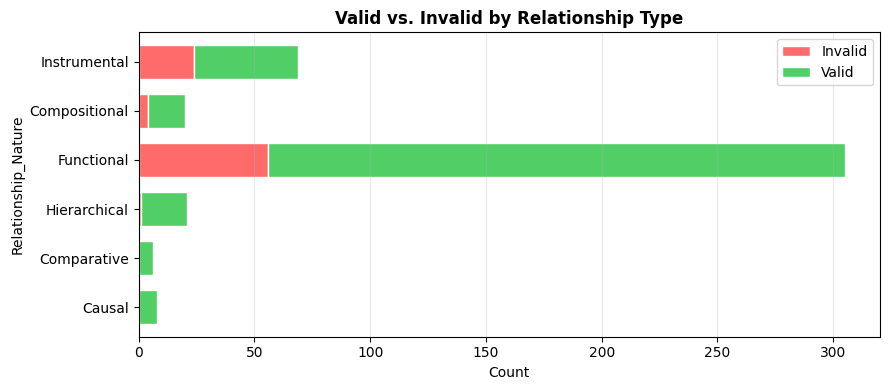

Saved error_analysis_rel_type


In [21]:
# Relationship type cross-tab: valid vs invalid
ct = pd.crosstab(ann['Relationship_Nature'], ann['Validation'],
                 values=ann['Validation'], aggfunc='count', normalize='index')
ct.columns = ['Invalid_rate','Valid_rate']
ct = ct.sort_values('Valid_rate', ascending=False)
print(ct.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ct_abs = pd.crosstab(ann['Relationship_Nature'], ann['Validation'])
ct_abs.columns = ['Invalid','Valid']
ct_abs = ct_abs.loc[ct.index]  # same order
ct_abs.plot(kind='barh', stacked=True, ax=ax, color=['#ff6b6b','#51cf66'],
            edgecolor='white', width=0.7)
ax.set_xlabel('Count'); ax.set_title('Valid vs. Invalid by Relationship Type', fontweight='bold')
ax.grid(axis='x', alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout(); save_fig('error_analysis_rel_type')


## 9. Inter-Annotator Agreement (IAA)

A second domain expert independently annotated **274 of the 429 sampled relationships** across
three domains (Machine Learning, Computational, Experimental Workflow). The Microscopy domain
(155 pairs) was annotated by a single expert only.

We compute **Cohen's κ** as the primary IAA metric and report percentage agreement as a
secondary measure. The κ interpretation follows Landis & Koch (1977):
- 0.41–0.60 → Moderate
- 0.61–0.80 → Substantial  
- 0.81–1.00 → Almost perfect

In [ ]:
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import numpy as np

# ── Column mapping per sheet ──────────────────────────────────────────────────
SHEET_COLS = {
    'Machine Learning':    ('Validation', 'Validation_2'),
    'Computational':       ('Validation', 'Validation_2'),
    'Experimental Workflow': ('Validation', 'Anotator_2'),
}
CERTAINTY_COLS = {
    'Machine Learning':    ('certainty', 'Certainty_2'),
    'Computational':       ('certainty', 'certainty_2'),
    'Experimental Workflow': ('certainty', 'Certa'),
}

iaa_rows = []
all_v1, all_v2 = [], []

for sheet, (v1_col, v2_col) in SHEET_COLS.items():
    df = pd.read_excel(os.path.join(DATA_DIR, 'ReproduceMeON_Sample_annotated.xlsx'),
                       sheet_name=sheet)
    v1 = df[v1_col].values.astype(int)
    v2 = df[v2_col].values.astype(int)
    kappa   = cohen_kappa_score(v1, v2)
    agree   = (v1 == v2).mean()
    tp = int(((v1==1) & (v2==1)).sum())
    tn = int(((v1==0) & (v2==0)).sum())
    fp = int(((v1==1) & (v2==0)).sum())  # A1 valid, A2 invalid
    fn = int(((v1==0) & (v2==1)).sum())  # A1 invalid, A2 valid
    iaa_rows.append({'Domain': sheet, 'n': len(v1), 'κ (Cohen)': round(kappa, 3),
                     'Agreement %': round(agree*100, 1),
                     'TP': tp, 'TN': tn, 'FP (A1=1,A2=0)': fp, 'FN (A1=0,A2=1)': fn})
    all_v1.extend(v1.tolist())
    all_v2.extend(v2.tolist())

kappa_all = cohen_kappa_score(all_v1, all_v2)
agree_all = (np.array(all_v1) == np.array(all_v2)).mean()
iaa_rows.append({'Domain': 'Overall (excl. Microscopy)', 'n': len(all_v1),
                 'κ (Cohen)': round(kappa_all, 3),
                 'Agreement %': round(agree_all*100, 1),
                 'TP': sum(1 for a,b in zip(all_v1,all_v2) if a==1 and b==1),
                 'TN': sum(1 for a,b in zip(all_v1,all_v2) if a==0 and b==0),
                 'FP (A1=1,A2=0)': sum(1 for a,b in zip(all_v1,all_v2) if a==1 and b==0),
                 'FN (A1=0,A2=1)': sum(1 for a,b in zip(all_v1,all_v2) if a==0 and b==1)})

iaa_df = pd.DataFrame(iaa_rows)
print(iaa_df.to_string(index=False))
print(f"\nLandis & Koch (1977): κ=0.723 → Substantial Agreement")


In [ ]:
# ── Figure: IAA kappa + agreement bar chart ───────────────────────────────────
domains_plot = ['Machine\nLearning', 'Computational', 'Experimental\nWorkflow', 'Overall']
kappas  = [0.671, 0.817, 0.720, 0.723]
agrees  = [87.6,  94.7,  90.7,  90.5]

DOMAIN_COLORS = ['#2471A3', '#117A65', '#D35400', '#4A235A']
x = np.arange(len(domains_plot))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, kappas, width, color=DOMAIN_COLORS, alpha=0.85, label="Cohen's κ")
bars2 = ax2.bar(x + width/2, agrees, width, color=DOMAIN_COLORS, alpha=0.45,
                edgecolor=DOMAIN_COLORS, linewidth=1.2, label='Agreement %')

ax1.set_ylabel("Cohen's κ", fontsize=12)
ax2.set_ylabel('Percent Agreement (%)', fontsize=12)
ax1.set_ylim(0, 1.05)
ax2.set_ylim(0, 110)
ax1.set_xticks(x)
ax1.set_xticklabels(domains_plot, fontsize=11)
ax1.axhline(0.61, color='gray', ls='--', lw=1.2, label='Substantial threshold (κ=0.61)')
ax1.axhline(0.81, color='black', ls=':', lw=1.2, label='Almost-perfect threshold (κ=0.81)')

for bar, k in zip(bars1, kappas):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'κ={k}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
for bar, a in zip(bars2, agrees):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{a}%', ha='center', va='bottom', fontsize=9.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)
ax1.set_title("Inter-Annotator Agreement by Domain\n(274 dual-annotated pairs)", fontsize=12)
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'iaa_agreement.png')
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.savefig(out_path.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved {out_path}')
